## Progetto Deep Learning - Project 3 - Detection and Localisation of Bone Fractures on X-rays 

*Salvatore Emmanuel La Porta - 1000081957*



## 1. Setup e import

Importo tutte le librerie e definisco le costanti e i path che servono per il progetto.

In [3]:
import os
import sys
import shutil
import subprocess
from pathlib import Path
from collections import Counter
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml
import cv2
import pandas as pd

from ultralytics import YOLO

BASE_DIR         = Path("Progetto_DL_1000081957_data")
DATASETS_DIR     = BASE_DIR / "datasets"
ORIGINALS_DIR    = DATASETS_DIR / "originals"
PREPROCESSED_DIR = DATASETS_DIR / "preprocessed"
RUNS_DIR         = BASE_DIR / "runs"
FRACATLAS_DIR   = ORIGINALS_DIR / "fracatlas"
PKDARABI_DIR    = ORIGINALS_DIR / "pkdarabi"

PKDARABI_ORIG = BASE_DIR / "datasets" / "originals" / "pkdarabi"
PKDARABI_PREP = BASE_DIR / "datasets" / "preprocessed" / "pkdarabi"
PKDARABI_CLAHE = BASE_DIR / "datasets" / "preprocessed" / "pkdarabi_clahe"
PKDARABI_AUG = BASE_DIR / "datasets" / "preprocessed" / "pkdarabi_aug"




for d in [BASE_DIR, DATASETS_DIR, ORIGINALS_DIR, PREPROCESSED_DIR,
          RUNS_DIR, FRACATLAS_DIR, PKDARABI_DIR]:
    d.mkdir(parents=True, exist_ok=True)

KAGGLE_PKDARABI  = "pkdarabi/bone-fracture-detection-computer-vision-project"
KAGGLE_FRACATLAS = "mahmudulhasantasin/fracatlas-original-dataset"

print(f"BASE_DIR        : {BASE_DIR.resolve()}")
print(f"ORIGINALS_DIR   : {ORIGINALS_DIR.resolve()}")
print(f"PREPROCESSED_DIR: {PREPROCESSED_DIR.resolve()}")
print(f"RUNS_DIR        : {RUNS_DIR.resolve()}")

BASE_DIR        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data
ORIGINALS_DIR   : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\originals
PREPROCESSED_DIR: C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed
RUNS_DIR        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs


## 2. Download e analisi esplorativa dei dataset

Dalla documentazione del progetto ho a disposizione due dataset:

- **FracAtlas** (`mahmudulhasantasin/fracatlas-original-dataset`): annotazioni disponibili in vari formati tra cui YOLO. Le immagini sono divise in Fractured e Non_fractured, senza split train/valid/test predefiniti bilanciati.
- **Bone Fracture Detection** (`pkdarabi/bone-fracture-detection-computer-vision-project`): versione preprocessata in formato YOLO, con split train/valid/test già definiti e 7 classi anatomiche.

Scarico entrambi, ne analizzo la struttura e uso i dati per decidere su quale lavorare.

In [2]:
# --- pkdarabi: ha data.yaml, download diretto ---
def download_pkdarabi(kaggle_slug, dest_dir):
    cache_path = Path(kagglehub.dataset_download(kaggle_slug))
    print(f"Cache: {cache_path}")

    yaml_candidates = list(cache_path.rglob("data.yaml"))
    assert yaml_candidates, f"data.yaml non trovato in {cache_path}"

    src_root = yaml_candidates[0].parent
    print(f"Sorgente: {src_root}")

    if not (dest_dir / "train" / "images").exists():
        for item in src_root.iterdir():
            dst = dest_dir / item.name
            if dst.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)
        print("Copia completata.")
    else:
        print("(skip) dataset gia' presente.")

    return dest_dir / "data.yaml"

print("=== Download pkdarabi ===")
pkdarabi_yaml_path = download_pkdarabi(KAGGLE_PKDARABI, PKDARABI_DIR)

=== Download pkdarabi ===
Cache: C:\Users\emm97\.cache\kagglehub\datasets\pkdarabi\bone-fracture-detection-computer-vision-project\versions\2
Sorgente: C:\Users\emm97\.cache\kagglehub\datasets\pkdarabi\bone-fracture-detection-computer-vision-project\versions\2\bone fracture detection.v4-v4.yolov8
(skip) dataset gia' presente.


In [3]:
# --- FracAtlas: non ha data.yaml, struttura custom ---
def download_fracatlas(kaggle_slug, dest_dir):
    cache_path = Path(kagglehub.dataset_download(kaggle_slug))
    print(f"Cache: {cache_path}")

    src_root = cache_path / "FracAtlas"
    assert src_root.exists(), f"Cartella FracAtlas non trovata in {cache_path}"
    print(f"Sorgente: {src_root}")

    if not (dest_dir / "Annotations").exists():
        for item in src_root.iterdir():
            dst = dest_dir / item.name
            if dst.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)
        print("Copia completata.")
    else:
        print("(skip) dataset gia' presente.")

    return dest_dir

print("=== Download FracAtlas ===")
fracatlas_root = download_fracatlas(KAGGLE_FRACATLAS, FRACATLAS_DIR)

=== Download FracAtlas ===
Cache: C:\Users\emm97\.cache\kagglehub\datasets\mahmudulhasantasin\fracatlas-original-dataset\versions\1
Sorgente: C:\Users\emm97\.cache\kagglehub\datasets\mahmudulhasantasin\fracatlas-original-dataset\versions\1\FracAtlas
(skip) dataset gia' presente.


### 2.1 Analisi FracAtlas

FracAtlas non è in formato YOLO nativo: le annotazioni YOLO (txt) ci sono, ma le immagini non sono organizzate in split train/valid/test. La struttura è:

In [4]:
fracatlas_root = FRACATLAS_DIR

print("FracAtlas/")
for level1 in sorted(fracatlas_root.iterdir()):
    is_last1 = level1 == sorted(fracatlas_root.iterdir())[-1]
    prefix1 = "└── " if is_last1 else "├── "
    suffix = "/" if level1.is_dir() else ""
    print(f"{prefix1}{level1.name}{suffix}")
    if level1.is_dir():
        children = sorted(level1.iterdir())
        for i, level2 in enumerate(children):
            is_last2 = i == len(children) - 1
            prefix2 = ("    " if is_last1 else "│   ") + ("└── " if is_last2 else "├── ")
            suffix2 = "/" if level2.is_dir() else ""
            print(f"{prefix2}{level2.name}{suffix2}")

yolo_ann  = FRACATLAS_DIR / "Annotations" / "YOLO"
split_dir = FRACATLAS_DIR / "Utilities" / "Fracture Split"

# distribuzione fractured / background
all_txts  = list(yolo_ann.glob("*.txt"))
n_with_box = sum(1 for t in all_txts if t.read_text().strip())
n_empty    = len(all_txts) - n_with_box

print("\n==========\n")
print(f"Totale immagini    : {len(all_txts)}")
print(f"Con box (fratturate): {n_with_box}")
print(f"Background (sane)  : {n_empty}")
print(f"% background       : {n_empty / len(all_txts) * 100:.1f}%")

# split predefiniti (solo fratturate)
print("\nSplit predefiniti (solo immagini fratturate):")
for split_name in ["train", "valid", "test"]:
    csv = pd.read_csv(split_dir / f"{split_name}.csv")
    print(f"  {split_name:5s}: {len(csv):4d} immagini")

# metadati
df = pd.read_csv(FRACATLAS_DIR / "dataset.csv")
print(f"\ndataset.csv: {df.shape[0]} righe, colonne: {df.columns.tolist()}")
print(f"Immagini fratturate nel CSV: {df['fractured'].sum()}")
print(f"Immagini sane nel CSV      : {(df['fractured'] == 0).sum()}")

FracAtlas/
├── Annotations/
│   ├── COCO JSON/
│   ├── PASCAL VOC/
│   ├── VGG JSON/
│   └── YOLO/
├── dataset.csv
├── images/
│   ├── Fractured/
│   └── Non_fractured/
└── Utilities/
    ├── coco2yolo.ipynb
    ├── Fracture Split/
    └── yolo2voc.ipynb


Totale immagini    : 4084
Con box (fratturate): 718
Background (sane)  : 3366
% background       : 82.4%

Split predefiniti (solo immagini fratturate):
  train:  574 immagini
  valid:   82 immagini
  test :   61 immagini

dataset.csv: 4083 righe, colonne: ['image_id', 'hand', 'leg', 'hip', 'shoulder', 'mixed', 'hardware', 'multiscan', 'fractured', 'fracture_count', 'frontal', 'lateral', 'oblique']
Immagini fratturate nel CSV: 717
Immagini sane nel CSV      : 3366


I CSV di split contengono **solo le immagini fratturate**: le 3366 immagini sane non sono assegnate ad alcuno split. Per usare FracAtlas in un training YOLO corretto dovrei costruire gli split a mano, distribuendo le immagini di background in modo stratificato tra train, valid e test.

### 2.2 Analisi pkdarabi

In [5]:
# fix data.yaml
with open(pkdarabi_yaml_path, "r") as f:
    pkdarabi_cfg = yaml.safe_load(f)

correct_path = str(PKDARABI_DIR.resolve())
if pkdarabi_cfg.get("path") != correct_path:
    pkdarabi_cfg["path"] = correct_path
    with open(pkdarabi_yaml_path, "w") as f:
        yaml.dump(pkdarabi_cfg, f, default_flow_style=False, allow_unicode=True)
    print("data.yaml aggiornato:", correct_path)
else:
    print("data.yaml gia' corretto.")

CLASS_NAMES = pkdarabi_cfg["names"]
N_CLASSES   = len(CLASS_NAMES)

print(f"\nClassi ({N_CLASSES}): {list(CLASS_NAMES.values())}")

# conteggio per split
def count_labels(dataset_dir, split):
    lbl_dir = dataset_dir / split / "labels"
    class_counter = Counter()
    n_empty = 0
    box_areas = []
    for txt in lbl_dir.glob("*.txt"):
        lines = txt.read_text().strip().splitlines()
        if not lines:
            n_empty += 1
            continue
        for line in lines:
            parts = line.split()
            cls = int(parts[0])
            w, h = float(parts[3]), float(parts[4])
            class_counter[cls] += 1
            box_areas.append(w * h)
    return class_counter, n_empty, box_areas

totals    = {}
empties   = {}
all_areas = {}

for split in ["train", "valid", "test"]:
    counter, n_empty, areas = count_labels(PKDARABI_DIR, split)
    totals[split]    = counter
    empties[split]   = n_empty
    all_areas[split] = areas

print(f"\n{'Classe':<20} {'train':>6} {'valid':>6} {'test':>6}")
print("-" * 40)
for cls_id, cls_name in CLASS_NAMES.items():
    row = f"{cls_name:<20}"
    for split in ["train", "valid", "test"]:
        row += f" {totals[split][cls_id]:>6}"
    print(row)

print("-" * 40)
for split in ["train", "valid", "test"]:
    lbl_dir     = PKDARABI_DIR / split / "labels"
    n_total     = len(list(lbl_dir.glob("*.txt")))
    n_empty     = empties[split]
    n_with_box  = n_total - n_empty
    total_boxes = sum(totals[split].values())
    print(f"{split:5s} -> totale: {n_total:4d}  con box: {n_with_box:4d}  "
          f"background: {n_empty:4d}  % background: {n_empty/n_total*100:.1f}%  "
          f"box totali: {total_boxes:5d}")

data.yaml gia' corretto.

Classi (7): ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']

Classe                train  valid   test
----------------------------------------
elbow positive          339     29     17
fingers positive        531     48     27
forearm fracture        316     43     14
humerus fracture          3      0      0
humerus                 311     36     15
shoulder fracture       360     20     17
wrist positive          228     28      6
----------------------------------------
train -> totale: 3631  con box: 1804  background: 1827  % background: 50.3%  box totali:  2088
valid -> totale:  348  con box:  173  background:  175  % background: 50.3%  box totali:   204
test  -> totale:  169  con box:   83  background:   86  % background: 50.9%  box totali:    96


### 2.3 Scelta del dataset di lavoro

| Caratteristica         | FracAtlas        | pkdarabi          |
|------------------------|------------------|-------------------|
| Immagini totali        | 4083             | 4148              |
| % background           | 82.4%            | 50.3%             |
| Classi                 | 1 (fracture)     | 7 (anatomiche)    |
| Formato annotazioni    | YOLO             | YOLO              |
| Split predefiniti      | Solo fratturate  | Stratificati      |
| Costruzione split      | Manuale          | Pronta all'uso    |

Lo sbilanciamento dell'82.4% di background in FracAtlas è il limite principale: nei miei tentativi precedenti su questo dataset il modello arrivava al massimo a mAP50 = 0.265 con YOLOv11 Nano, con convergenza instabile e collassi numerici frequenti, dovuti al fatto che la classe `fracture` compariva poco nei batch.

pkdarabi invece ha il 50.3% di background distribuito in modo stratificato su tutti e tre gli split, quindi raddoppia di fatto la densità di segnale utile per step di training. Le 7 classi anatomiche le collasso a una sola classe `fracture` in fase di preprocessing, allineando la struttura a quella di FracAtlas e ai requisiti del progetto (detection e localizzazione).

**Dataset di lavoro**: pkdarabi, preprocessato a una sola classe `fracture`.

## 3. Preprocessing

Il dataset ha 7 classi anatomiche. Visto che lo scopo del progetto è solo capire se l'immagine contiene una frattura e dove, collasso le 7 classi a una unica classe `fracture` (id 0).

Per le immagini non fratturate, nel formato YOLO non servono annotazioni: un file label vuoto (o assente) dice al modello che in quella immagine non deve predire nessuna box. Non creo quindi una classe `not_fractured` come oggetto da localizzare: l'assenza di frattura non è un oggetto. Il modello impara implicitamente a non predire niente sulle immagini sane attraverso la objectness loss calcolata su questi esempi negativi.

Per ottenere questo risultato:

1. Copio la struttura del dataset da `originals/pkdarabi` a `preprocessed/pkdarabi`.
2. Per ogni file label `.txt`: rimappo tutti gli id delle classi a 0.
3. Aggiorno `data.yaml`: 1 classe, nome `fracture`.

In [6]:
def collapse_labels_to_single_class(src_dir, dst_dir):
    dst_dir.mkdir(parents=True, exist_ok=True)
    modified = 0
    copied = 0

    for label_file in src_dir.rglob("*.txt"):
        rel = label_file.relative_to(src_dir)
        dst_file = dst_dir / rel
        dst_file.parent.mkdir(parents=True, exist_ok=True)

        lines = label_file.read_text().splitlines()
        if not lines:
            dst_file.write_text("")
            copied += 1
            continue

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                parts[0] = "0"
                new_lines.append(" ".join(parts))
        dst_file.write_text("\n".join(new_lines) + "\n" if new_lines else "")
        modified += 1

    print(f"Label processati : {modified}")
    print(f"Label vuoti copiati: {copied}")


for split in ("train", "valid", "test"):
    src_img = PKDARABI_ORIG / split / "images"
    dst_img = PKDARABI_PREP / split / "images"
    if dst_img.exists():
        print(f"(skip) {split}/images gia' presente")
    else:
        shutil.copytree(src_img, dst_img)
        print(f"Copiato {split}/images")

print("\nProcesso label...")
collapse_labels_to_single_class(PKDARABI_ORIG, PKDARABI_PREP)

yaml_dst = PKDARABI_PREP / "data.yaml"
yaml_content = {
    "path": str(PKDARABI_PREP.resolve()),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    1,
    "names": ["fracture"],
}
with open(yaml_dst, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"\ndata.yaml scritto in: {yaml_dst}")
print(yaml_content)

Copiato train/images
Copiato valid/images
Copiato test/images

Processo label...
Label processati : 2061
Label vuoti copiati: 2088

data.yaml scritto in: Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\data.yaml
{'path': 'C:\\Users\\emm97\\Desktop\\Deep Learning\\Esame\\Progetto\\Progetto_DL_1000081957_data\\datasets\\preprocessed\\pkdarabi', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['fracture']}


Verifico adesso che il preprocessing sia andato a buon fine: in train/val/test deve esserci solo una classe con id 0 corrispondente a `fracture`.

In [7]:
def count_labels(split_dir):
    label_dir = split_dir / "labels"
    total = 0
    background = 0
    boxes = 0
    class_ids = set()

    for f in label_dir.glob("*.txt"):
        total += 1
        lines = [l for l in f.read_text().splitlines() if l.strip()]
        if not lines:
            background += 1
        else:
            boxes += len(lines)
            for l in lines:
                class_ids.add(l.split()[0])

    print(f"  Immagini totali : {total}")
    print(f"  Background      : {background} ({100*background/total:.1f}%)")
    print(f"  Con box         : {total - background}")
    print(f"  Box totali      : {boxes}")
    print(f"  Class id trovati: {class_ids}")

for split in ("train", "valid", "test"):
    print(f"\n[{split}]")
    count_labels(PKDARABI_PREP / split)


[train]
  Immagini totali : 3631
  Background      : 1827 (50.3%)
  Con box         : 1804
  Box totali      : 2088
  Class id trovati: {'0'}

[valid]
  Immagini totali : 348
  Background      : 175 (50.3%)
  Con box         : 173
  Box totali      : 204
  Class id trovati: {'0'}

[test]
  Immagini totali : 169
  Background      : 86 (50.9%)
  Con box         : 83
  Box totali      : 96
  Class id trovati: {'0'}


## 4. Exploratory Data Analysis

Prima di lanciare il training analizzo la struttura del dataset per motivare le scelte di preprocessing e gli iperparametri del modello.

### 4.1 Distribuzione delle classi: originale vs preprocessato

Il grafico mostra la distribuzione delle annotazioni per classe nel dataset originale (7 classi anatomiche) e nel dataset preprocessato (1 classe `fracture`). Il confronto conferma visivamente che il collasso è avvenuto correttamente e che nessuna annotazione si è persa.

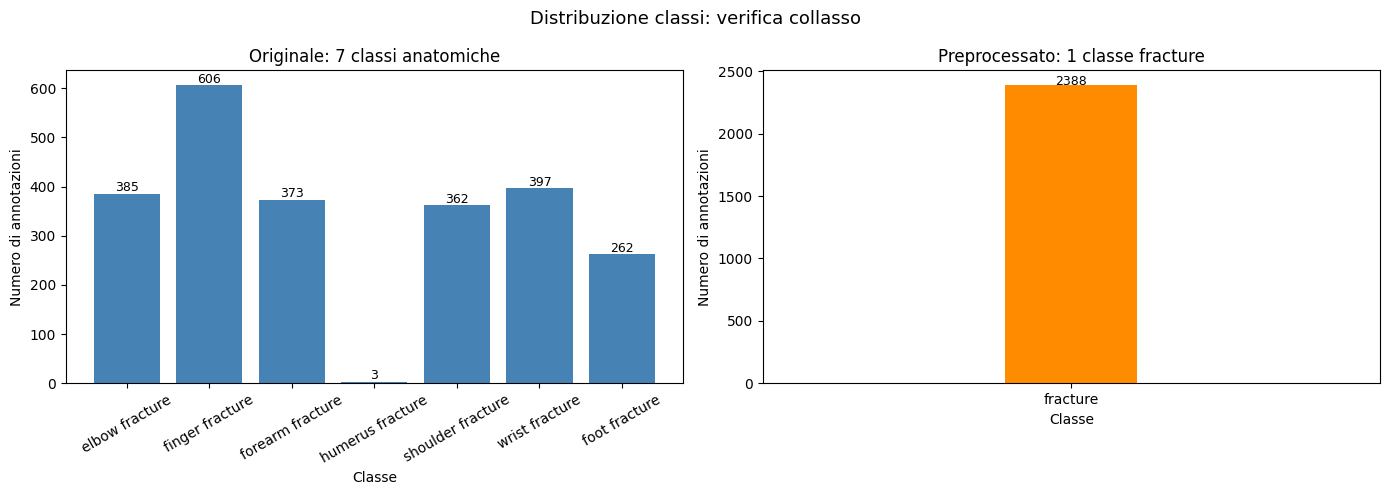

Totale annotazioni originale  : 2388
Totale annotazioni preprocessato: 2388
OK: nessuna annotazione persa.


In [8]:
def load_class_counts(dataset_dir, class_names):
    counts = {name: 0 for name in class_names}
    for label_file in dataset_dir.rglob("labels/*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                if cls_id < len(class_names):
                    counts[class_names[cls_id]] += 1
    return counts

ORIG_CLASSES = [
    "elbow fracture", "finger fracture", "forearm fracture",
    "humerus fracture", "shoulder fracture", "wrist fracture", "foot fracture"
]
PREP_CLASSES = ["fracture"]

counts_orig = load_class_counts(PKDARABI_ORIG, ORIG_CLASSES)
counts_prep = load_class_counts(PKDARABI_PREP, PREP_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts_orig.keys(), counts_orig.values(), color="steelblue")
axes[0].set_title("Originale: 7 classi anatomiche")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Numero di annotazioni")
axes[0].tick_params(axis="x", rotation=30)
for i, (k, v) in enumerate(counts_orig.items()):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

axes[1].bar(counts_prep.keys(), counts_prep.values(), color="darkorange", width=0.3)
axes[1].set_xlim(-0.7, 0.7)
axes[1].set_title("Preprocessato: 1 classe fracture")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Numero di annotazioni")
for i, (k, v) in enumerate(counts_prep.items()):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=9)

total_orig = sum(counts_orig.values())
total_prep = sum(counts_prep.values())
assert total_orig == total_prep, f"Annotazioni perse: {total_orig} orig vs {total_prep} prep"

plt.suptitle("Distribuzione classi: verifica collasso", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Totale annotazioni originale  : {total_orig}")
print(f"Totale annotazioni preprocessato: {total_prep}")
print("OK: nessuna annotazione persa.")

### 4.2 Background vs fratturate per split

Ho scelto questo dataset principalmente perché un dataset YOLO ben costruito deve avere una distribuzione stabile di immagini background e immagini con annotazioni in tutti e tre gli split. Uno sbilanciamento forte o una distribuzione disomogenea tra split (come in FracAtlas) introdurrebbe bias nella valutazione delle metriche.

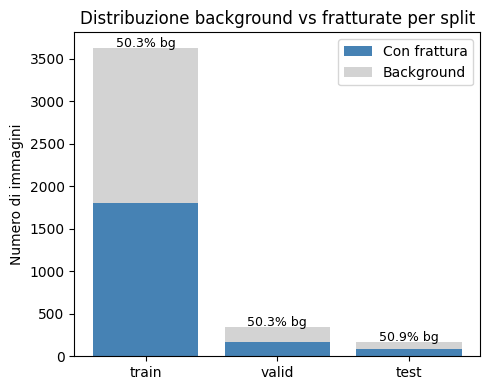

train  | totale: 3631 | annotate: 1804 | background: 1827 | box: 2088
valid  | totale:  348 | annotate:  173 | background:  175 | box:  204
test   | totale:  169 | annotate:   83 | background:   86 | box:   96


In [9]:
def split_stats(dataset_dir):
    stats = {}
    for split in ("train", "valid", "test"):
        label_dir = dataset_dir / split / "labels"
        total, background, boxes = 0, 0, 0
        for f in label_dir.glob("*.txt"):
            total += 1
            lines = [l for l in f.read_text().splitlines() if l.strip()]
            if not lines:
                background += 1
            else:
                boxes += len(lines)
        stats[split] = {
            "total": total,
            "background": background,
            "annotated": total - background,
            "boxes": boxes,
        }
    return stats

stats = split_stats(PKDARABI_PREP)

splits = list(stats.keys())
annotated = [stats[s]["annotated"] for s in splits]
background = [stats[s]["background"] for s in splits]

x = range(len(splits))
fig, ax = plt.subplots(figsize=(5, 4))
bars_ann = ax.bar(x, annotated, label="Con frattura", color="steelblue")
bars_bg  = ax.bar(x, background, bottom=annotated, label="Background", color="lightgray")

for i, s in enumerate(splits):
    total = stats[s]["total"]
    pct_bg = 100 * stats[s]["background"] / total
    ax.text(i, total + 10, f"{pct_bg:.1f}% bg", ha="center", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(splits)
ax.set_ylabel("Numero di immagini")
ax.set_title("Distribuzione background vs fratturate per split")
ax.legend()
plt.tight_layout()
plt.show()

for s in splits:
    st = stats[s]
    print(f"{s:6s} | totale: {st['total']:4d} | annotate: {st['annotated']:4d} | "
          f"background: {st['background']:4d} | box: {st['boxes']:4d}")

### 4.3 Distribuzione delle dimensioni dei bounding box

Le dimensioni delle box (già normalizzate rispetto all'immagine, range [0,1]) determinano la scala degli oggetti che il modello deve rilevare. Box molto piccole richiedono una risoluzione di input (`imgsz`) alta: se un oggetto occupa l'1% dell'immagine, a `imgsz=640` risulta in pochi pixel ed è difficilmente rilevabile dalla rete. Questo grafico mi serve per decidere il valore di `imgsz`.

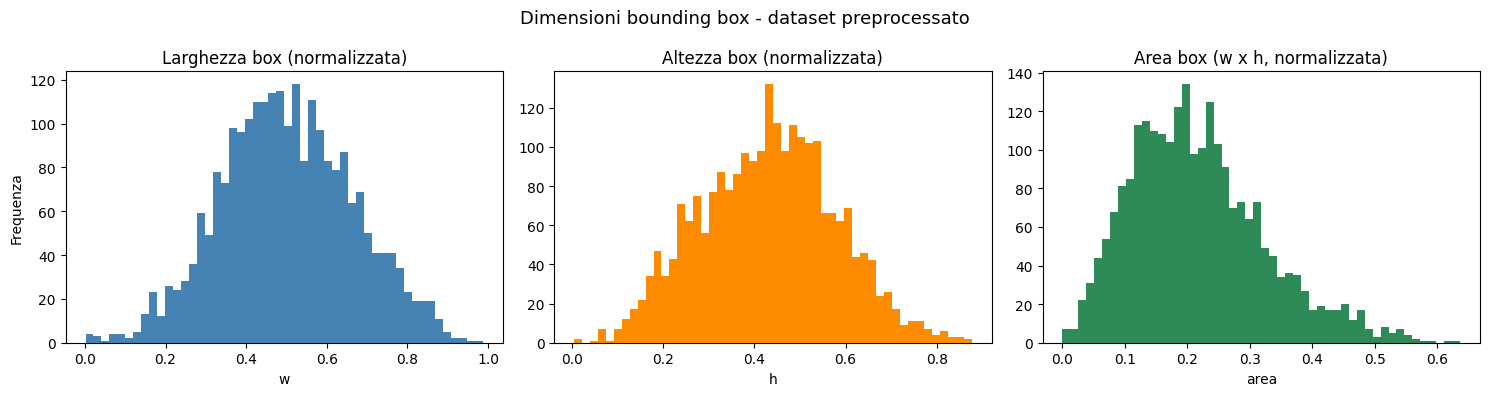

Box totali     : 2388
Area mediana   : 0.2027
Area media     : 0.2171
Area < 1%      : 6 (0.3%)
Area < 5%      : 65 (2.7%)
Area > 10%     : 2093 (87.6%)


In [10]:
def load_box_sizes(dataset_dir):
    widths, heights, areas = [], [], []
    for label_file in dataset_dir.rglob("labels/*.txt"):
        for line in label_file.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                w, h = float(parts[3]), float(parts[4])
                widths.append(w)
                heights.append(h)
                areas.append(w * h)
    return widths, heights, areas

widths, heights, areas = load_box_sizes(PKDARABI_PREP)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Larghezza box (normalizzata)")
axes[0].set_xlabel("w")
axes[0].set_ylabel("Frequenza")

axes[1].hist(heights, bins=50, color="darkorange", edgecolor="none")
axes[1].set_title("Altezza box (normalizzata)")
axes[1].set_xlabel("h")

axes[2].hist(areas, bins=50, color="seagreen", edgecolor="none")
axes[2].set_title("Area box (w x h, normalizzata)")
axes[2].set_xlabel("area")

plt.suptitle("Dimensioni bounding box - dataset preprocessato", fontsize=13)
plt.tight_layout()
plt.show()

areas_arr = np.array(areas)
print(f"Box totali     : {len(areas_arr)}")
print(f"Area mediana   : {np.median(areas_arr):.4f}")
print(f"Area media     : {np.mean(areas_arr):.4f}")
print(f"Area < 1%      : {(areas_arr < 0.01).sum()} ({100*(areas_arr < 0.01).mean():.1f}%)")
print(f"Area < 5%      : {(areas_arr < 0.05).sum()} ({100*(areas_arr < 0.05).mean():.1f}%)")
print(f"Area > 10%     : {(areas_arr > 0.10).sum()} ({100*(areas_arr > 0.10).mean():.1f}%)")

Rispetto a FracAtlas, le bounding box di questo dataset sono molto più grandi: circa il 20% dell'area dell'immagine in media, e quasi tutte superano almeno il 10%.

Con **`imgsz=640`** una box tipica occupa circa 128x128 pixel effettivi, sufficienti per riconoscere la frattura.

### 4.4 Immagini con annotazioni

Visualizzo un campione di immagini con le bounding box disegnate per verificare la qualità delle annotazioni e avere un riferimento visivo di cosa il modello deve rilevare.

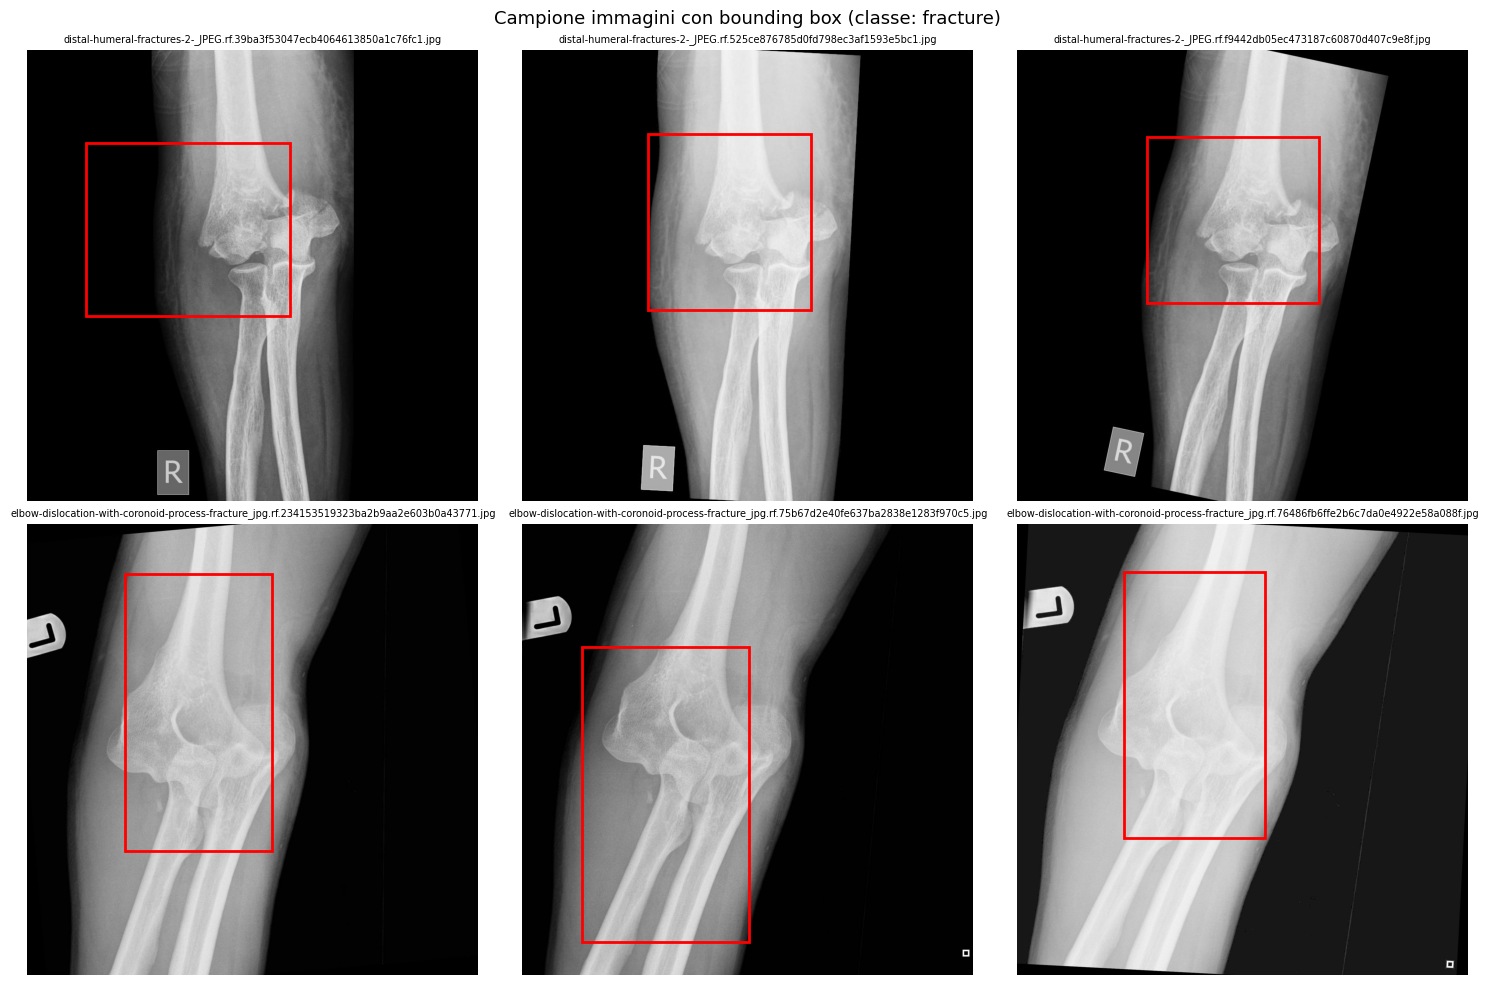

In [11]:
def draw_boxes(img_path, label_path, class_names):
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(img, cmap="gray")

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, class_names[cls_id], color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))

    ax.axis("off")
    ax.set_title(img_path.name, fontsize=8)
    return fig


train_img_dir   = PKDARABI_PREP / "train" / "images"
train_label_dir = PKDARABI_PREP / "train" / "labels"

# Seleziona le prime 6 immagini che hanno almeno una box
samples = []
for img_path in sorted(train_img_dir.iterdir()):
    label_path = train_label_dir / (img_path.stem + ".txt")
    if label_path.exists():
        lines = [l for l in label_path.read_text().splitlines() if l.strip()]
        if lines:
            samples.append((img_path, label_path))
    if len(samples) == 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (img_path, label_path) in zip(axes.flat, samples):
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    ax.imshow(img, cmap="gray")
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        rect = patches.Rectangle(
            (x1, y1), bw * w, bh * h,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis("off")

plt.suptitle("Campione immagini con bounding box (classe: fracture)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Training baseline - YOLOv11 Nano

Il primo modello che addestro è la baseline: YOLOv11 Nano con una configurazione conservativa, pensata per avere un training stabile e riproducibile sull'hardware che uso.

### Parametri di training

***Modello: yolo11n.pt***
Nano è il modello più leggero della famiglia YOLOv11 (~2.6M parametri). Lo inizializzo con i pesi pre-allenati su COCO (transfer learning), che forniscono feature generali di basso livello (bordi, texture, forme) già utili per le radiografie, riducendo le epoche necessarie a convergere.

***imgsz=640***
Come visto nell'EDA, le box hanno area mediana del 20% dell'immagine. A 640px una box tipica occupa circa 128x128 pixel, sufficiente per il Nano. Valori più alti aumenterebbero il consumo di VRAM senza beneficio misurabile su questo dataset.

***batch=16***
Valore di riferimento sicuro per il Nano a imgsz=640 (~1.5GB di VRAM con AMP). Batch più grandi (es. 32) avevano causato overflow fp16 e collasso del training in tentativi precedenti sullo stesso hardware. La BatchNorm è comunque stabile con 16 campioni per step anche con il ~50% di background.

***epochs=100***
Le curve di detection su dataset di queste dimensioni richiedono almeno 100 epoche per convergere. Con valori più bassi (50 epoche nei tentativi precedenti) il training si fermava durante una fase di oscillazione normale, prima del vero plateau.

***patience=25***
La mAP sul validation oscilla fisiologicamente di ±0.01-0.02 tra epoche consecutive. Una patience troppo bassa (es. 10) attiva l'early stopping durante queste oscillazioni normali. Con patience=25 il modello attraversa almeno 2-3 cicli di oscillazione prima dell'eventuale stop.

***optimizer=auto***
Lascio a Ultralytics la scelta dell'ottimizzatore in base al modello. Per YOLOv11 seleziona SGD con momentum=0.937 e weight_decay=0.0005, una configurazione tarata dagli autori su molti esperimenti.

***lr0=0.01, lrf=0.01***
Learning rate iniziale standard per fine-tuning da pesi COCO. Il decay durante il training è gestito dallo scheduler cosine di Ultralytics.

***mosaic=1.0***
Il mosaic combina 4 immagini in una durante il training, aumentando la varianza dei campioni e la frequenza con cui il modello vede fratture per step. Con il 50% di background per split, il mosaic garantisce che ogni batch contenga esempi positivi. Non lo disabilito: nei tentativi precedenti `mosaic=0.0` aveva peggiorato la mAP da 0.265 a 0.213.

***cls=0.5***
Peso della classification loss. È il default di Ultralytics, ottimizzato su COCO. Con una sola classe il contributo della cls_loss è già minimo: alzarlo (es. a 1.0 in un tentativo precedente) aveva dimezzato la mAP destabilizzando il bilanciamento delle perdite.

***amp=True***
Automatic Mixed Precision: usa fp16 dove possibile per ridurre VRAM e velocizzare il training. Con batch=16 e imgsz=640 il rischio di overflow fp16 è basso. Se compaiono NaN nelle prime epoche, è il primo parametro da disabilitare per diagnosticare il problema.

In [12]:
BASELINE_CFG = {
    "model"    : "yolo11n.pt",
    "data"     : str((PKDARABI_PREP / "data.yaml").resolve()),
    "imgsz"    : 640,
    "batch"    : 16,
    "epochs"   : 100,
    "patience" : 25,
    "optimizer": "auto",
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "mosaic"   : 1.0,
    "cls"      : 0.5,
    "amp"      : True,
    "project"  : str((BASE_DIR / "runs").resolve()),
    "name"     : "baseline_nano",
    "exist_ok" : False,
}

for k, v in BASELINE_CFG.items():
    print(f"  {k:<12}: {v}")

  model       : yolo11n.pt
  data        : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\data.yaml
  imgsz       : 640
  batch       : 16
  epochs      : 100
  patience    : 25
  optimizer   : auto
  lr0         : 0.01
  lrf         : 0.01
  mosaic      : 1.0
  cls         : 0.5
  amp         : True
  project     : C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs
  name        : baseline_nano
  exist_ok    : False


In [13]:
model = YOLO(BASELINE_CFG["model"])
results = model.train(**BASELINE_CFG)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_r

Questa cella serve a riprendere l'allenamento da `last.pt` (che Ultralytics salva automaticamente) nel caso si sia interrotto.

In [ ]:
BASELINE_LAST = BASE_DIR / "runs" / "baseline_nano" / "weights" / "last.pt"

assert BASELINE_LAST.exists(), f"Checkpoint non trovato: {BASELINE_LAST}"

model_resume = YOLO(str(BASELINE_LAST))
results_resume = model_resume.train(resume=True)

Carico ora i pesi migliori (`best.pt`) e valuto il modello su validation e test set separatamente.

In [14]:
model_baseline = YOLO(str(BASELINE_BEST))

metrics_val = model_baseline.val(
    data=str((PKDARABI_PREP / "data.yaml").resolve()),
    split="val",
    imgsz=640,
    batch=16,
    project=str((BASE_DIR / "runs").resolve()),
    name="baseline_nano_eval_val",
    exist_ok=True,
    verbose=False,
)

metrics_test = model_baseline.val(
    data=str((PKDARABI_PREP / "data.yaml").resolve()),
    split="test",
    imgsz=640,
    batch=16,
    project=str((BASE_DIR / "runs").resolve()),
    name="baseline_nano_eval_test",
    exist_ok=True,
    verbose=False,
)

def print_metrics(label, m):
    p  = m.box.mp
    r  = m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    print(f"\n=== {label} ===")
    print(f"  mAP50    : {m.box.map50:.4f}")
    print(f"  mAP50-95 : {m.box.map:.4f}")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall   : {r:.4f}")
    print(f"  F1       : {f1:.4f}")

print_metrics("Baseline Nano - Validation", metrics_val)
print_metrics("Baseline Nano - Test", metrics_test)

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 10.42.9 MB/s, size: 8.9 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi\valid\labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 6.2it/s 3.6s0.1s
                   all        348        204      0.405      0.298      0.292        0.1
Speed: 1.8ms preprocess, 4.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\baseline_nano_eval_val
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop

| Metrica    | Validation | Test   |
|------------|------------|--------|
| mAP50      | 0.2920     | 0.2131 |
| mAP50-95   | 0.1000     | 0.0543 |
| Precision  | 0.4055     | 0.2621 |
| Recall     | 0.2975     | 0.2917 |
| F1         | 0.3432     | 0.2761 |

Il modello converge in modo stabile: nessun collasso numerico, early stopping a epoca 83 su 100. Il gap val/test su mAP50 è di 0.079, che indica un overfitting moderato. Il recall è sostanzialmente allineato tra i due split (0.298 vs 0.292), quindi la capacità del modello di trovare le fratture è consistente. Il calo principale sul test riguarda la precision (0.406 vs 0.262): il modello genera più falsi positivi su immagini che non ha mai visto durante la selezione del best checkpoint.

È il comportamento atteso per una baseline non ottimizzata: il modello sa trovare le fratture (recall stabile) ma non è ancora abbastanza selettivo (precision bassa sul test). I prossimi passi si concentreranno su questo gap.

## 6. K-Fold Cross-Validation

Le metriche ottenute con lo split fisso (train 3631, valid 348, test 169) sono basse e potenzialmente instabili. Il problema è strutturale: con solo 169 immagini di test (4% del totale) e 348 di validation (8.4%), una manciata di immagini difficili sposta sensibilmente le metriche, e il *best checkpoint* viene selezionato su un val set molto piccolo, con il rischio di overfittare alla particolare composizione di quello split.

La tecnica standard per dataset di piccole dimensioni (<5K immagini) in medical imaging è la **K-Fold Cross-Validation stratificata**:

1. Unisco tutte le immagini in un unico pool (4148 immagini).
2. Stratifico per presenza di frattura (binario: 1 se l'immagine ha almeno una box, 0 se è background), così che ogni fold contenga la stessa proporzione di fratturate e sane.
3. Divido in K=5 fold da circa 830 immagini ciascuno.
4. Per ogni fold k: alleno un modello su K-1 fold (3318 immagini) e lo valuto sul fold rimanente (830 immagini).
5. Riporto **media ± deviazione standard** delle metriche sui 5 fold.

Vantaggi rispetto allo split fisso:

- ogni immagine viene usata esattamente una volta come validation;
- il validation set effettivo passa da 348 a ~830 immagini → metriche più stabili;
- si neutralizza la "lotteria dello split": il test set originale da 169 immagini potrebbe essere semplicemente più difficile della media;
- la media ± std dà una stima più onesta della performance reale del modello.

Per un confronto pulito con la baseline uso gli **stessi iperparametri** di `BASELINE_CFG` (yolo11n, imgsz=640, batch=16, epochs=100, patience=25, ecc.). L'unica cosa che cambia è lo split dei dati.

In [4]:
from sklearn.model_selection import StratifiedKFold

PKDARABI_KFOLD = DATASETS_DIR / "preprocessed" / "pkdarabi_kfold"
N_FOLDS = 5
KFOLD_SEED = 42

# raccolta di tutte le immagini con etichetta binaria has_fracture
all_imgs = []
all_labels = []

for split in ("train", "valid", "test"):
    img_dir = PKDARABI_PREP / split / "images"
    lbl_dir = PKDARABI_PREP / split / "labels"
    for img in sorted(img_dir.iterdir()):
        if img.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
            continue
        lbl = lbl_dir / (img.stem + ".txt")
        has_fx = lbl.exists() and any(l.strip() for l in lbl.read_text().splitlines())
        all_imgs.append((img, lbl if lbl.exists() else None))
        all_labels.append(int(has_fx))

n_total = len(all_imgs)
n_fx = sum(all_labels)
n_bg = n_total - n_fx
print(f"Pool totale: {n_total} immagini")
print(f"  fratturate: {n_fx} ({100*n_fx/n_total:.1f}%)")
print(f"  background: {n_bg} ({100*n_bg/n_total:.1f}%)")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=KFOLD_SEED)
folds = list(skf.split(all_imgs, all_labels))

print(f"\nDistribuzione per fold (stratificata su has_fracture):")
for k, (train_idx, val_idx) in enumerate(folds):
    val_labels = [all_labels[i] for i in val_idx]
    train_labels = [all_labels[i] for i in train_idx]
    print(f"  fold {k}: train={len(train_idx)} (fx={sum(train_labels)}, bg={len(train_labels)-sum(train_labels)}), "
          f"val={len(val_idx)} (fx={sum(val_labels)}, bg={len(val_labels)-sum(val_labels)})")

Pool totale: 4148 immagini
  fratturate: 2060 (49.7%)
  background: 2088 (50.3%)

Distribuzione per fold (stratificata su has_fracture):
  fold 0: train=3318 (fx=1648, bg=1670), val=830 (fx=412, bg=418)
  fold 1: train=3318 (fx=1648, bg=1670), val=830 (fx=412, bg=418)
  fold 2: train=3318 (fx=1648, bg=1670), val=830 (fx=412, bg=418)
  fold 3: train=3319 (fx=1648, bg=1671), val=829 (fx=412, bg=417)
  fold 4: train=3319 (fx=1648, bg=1671), val=829 (fx=412, bg=417)


In [ ]:
def materialize_fold(fold_idx, train_idx, val_idx):
    fold_dir = PKDARABI_KFOLD / f"fold_{fold_idx}"
    train_img_dir = fold_dir / "train" / "images"
    val_img_dir = fold_dir / "val" / "images"

    # idempotenza: se gia' completo, skip
    if train_img_dir.exists() and val_img_dir.exists():
        actual_train = sum(1 for _ in train_img_dir.iterdir())
        actual_val = sum(1 for _ in val_img_dir.iterdir())
        if actual_train == len(train_idx) and actual_val == len(val_idx):
            print(f"  fold {fold_idx}: gia' presente (train={actual_train}, val={actual_val}), skip")
            return fold_dir

    for split in ("train", "val"):
        (fold_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (fold_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    for split_name, indices in [("train", train_idx), ("val", val_idx)]:
        for i in indices:
            img_path, lbl_path = all_imgs[i]
            dst_img = fold_dir / split_name / "images" / img_path.name
            if not dst_img.exists():
                shutil.copy2(img_path, dst_img)
            dst_lbl = fold_dir / split_name / "labels" / (img_path.stem + ".txt")
            if not dst_lbl.exists():
                if lbl_path is not None:
                    shutil.copy2(lbl_path, dst_lbl)
                else:
                    dst_lbl.write_text("")

    yaml_content = {
        "path": str(fold_dir.resolve()),
        "train": "train/images",
        "val": "val/images",
        "nc": 1,
        "names": ["fracture"],
    }
    with open(fold_dir / "data.yaml", "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)

    print(f"  fold {fold_idx}: creato (train={len(train_idx)}, val={len(val_idx)})")
    return fold_dir


PKDARABI_KFOLD.mkdir(parents=True, exist_ok=True)
print(f"Creazione fold in: {PKDARABI_KFOLD.resolve()}\n")
for k, (tr, vl) in enumerate(folds):
    materialize_fold(k, tr, vl)

print("\nFatto.")

### 6.1 Training sui 5 fold

Lancio un training per ogni fold con gli stessi iperparametri della baseline (`BASELINE_CFG`). L'unica differenza è il `data.yaml`, che punta allo split del fold corrente. Tempo totale stimato: circa 5 ore.

La cella è idempotente: se per un fold esiste già `best.pt`, il training viene saltato. Così posso rilanciare la cella senza ripartire da zero.

In [16]:
KFOLD_CFG_BASE = {
    "model"    : "yolo11n.pt",
    "imgsz"    : 640,
    "batch"    : 16,
    "epochs"   : 100,
    "patience" : 25,
    "optimizer": "auto",
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "mosaic"   : 1.0,
    "cls"      : 0.5,
    "amp"      : True,
    "project"  : str((BASE_DIR / "runs").resolve()),
    "exist_ok" : False,
}

for k in range(N_FOLDS):
    fold_data_yaml = PKDARABI_KFOLD / f"fold_{k}" / "data.yaml"
    run_name = f"kfold_nano_fold{k}"
    run_dir = BASE_DIR / "runs" / run_name
    best_pt = run_dir / "weights" / "best.pt"

    if best_pt.exists():
        print(f"=== fold {k}: best.pt gia' presente in {run_dir}, skip ===\n")
        continue

    print(f"\n=== Training fold {k}/{N_FOLDS-1} ===")
    cfg = {
        **KFOLD_CFG_BASE,
        "data": str(fold_data_yaml.resolve()),
        "name": run_name,
    }
    model = YOLO(cfg["model"])
    model.train(**cfg)

=== fold 0: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold0, skip ===

=== fold 1: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold1, skip ===

=== fold 2: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold2, skip ===

=== fold 3: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_fold3, skip ===


=== Training fold 4/4 ===
New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\

Se un training si interrompe, imposto `RESUME_FOLD` al fold da riprendere e lancio la cella sotto. Ultralytics riparte da `last.pt` da sola.

In [ ]:
RESUME_FOLD = 4  # cambiare con il fold da riprendere

LAST_PT = BASE_DIR / "runs" / f"kfold_nano_fold{RESUME_FOLD}" / "weights" / "last.pt"
assert LAST_PT.exists(), f"Checkpoint non trovato: {LAST_PT}"

model_resume = YOLO(str(LAST_PT))
results_resume = model_resume.train(resume=True)

### 6.2 Valutazione e aggregazione

Per ogni fold carico i pesi `best.pt` e valuto sul val del fold (cioè sulle immagini che quel modello non ha mai visto). Poi calcolo media e deviazione standard delle metriche sui 5 fold: questa è la stima onesta della performance del modello sul dataset.

In [17]:
fold_metrics = []

for k in range(N_FOLDS):
    fold_data_yaml = PKDARABI_KFOLD / f"fold_{k}" / "data.yaml"
    best_pt = BASE_DIR / "runs" / f"kfold_nano_fold{k}" / "weights" / "best.pt"

    assert best_pt.exists(), f"best.pt non trovato per fold {k}: {best_pt}"

    model_k = YOLO(str(best_pt))
    m = model_k.val(
        data=str(fold_data_yaml.resolve()),
        split="val",
        imgsz=640,
        batch=16,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"kfold_nano_fold{k}_eval",
        exist_ok=True,
        verbose=False,
    )
    p, r = m.box.mp, m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    fold_metrics.append({
        "fold": k,
        "mAP50": m.box.map50,
        "mAP50-95": m.box.map,
        "Precision": p,
        "Recall": r,
        "F1": f1,
    })

df_fold = pd.DataFrame(fold_metrics)
print("=== Metriche per fold ===")
print(df_fold.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== Aggregato (media +/- std sui 5 fold) ===")
for col in ("mAP50", "mAP50-95", "Precision", "Recall", "F1"):
    mu, sd = df_fold[col].mean(), df_fold[col].std()
    print(f"  {col:<10}: {mu:.4f} +/- {sd:.4f}")

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 6.71.0 MB/s, size: 11.0 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_kfold\fold_0\val\labels.cache... 830 images, 418 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.8it/s 10.8s0.2s
                   all        830        474      0.708      0.555      0.645      0.317
Speed: 2.9ms preprocess, 4.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\kfold_nano_fold0_eval
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 

### 6.3 Risultati K-Fold e confronto con baseline

#### Metriche per fold (best epoch sulla val del fold)

| Fold | mAP50  | mAP50-95 | Precision | Recall | F1     |
|------|--------|----------|-----------|--------|--------|
| 0    | 0.6461 | 0.3161   | 0.7051    | 0.5570 | 0.6223 |
| 1    | 0.6600 | 0.3248   | 0.7066    | 0.5946 | 0.6458 |
| 2    | 0.6801 | 0.3524   | 0.7894    | 0.5954 | 0.6788 |
| 3    | 0.6115 | 0.3005   | 0.7151    | 0.5189 | 0.6014 |
| 4    | 0.6526 | 0.3448   | 0.7379    | 0.5619 | 0.6380 |

#### Aggregato sui 5 fold

| Metrica    | Media  | Std    |
|------------|--------|--------|
| mAP50      | 0.6501 | 0.0250 |
| mAP50-95   | 0.3277 | 0.0211 |
| Precision  | 0.7308 | 0.0353 |
| Recall     | 0.5655 | 0.0316 |
| F1         | 0.6373 | 0.0288 |

#### Confronto diretto con la baseline a split fisso

| Metrica    | Baseline Val | Baseline Test | K-Fold (media ± std)  | Guadagno vs Test |
|------------|--------------|---------------|------------------------|------------------|
| mAP50      | 0.2920       | 0.2131        | **0.6501 ± 0.0250**    | +0.4370 (+205%)  |
| mAP50-95   | 0.1000       | 0.0543        | **0.3277 ± 0.0211**    | +0.2734 (+503%)  |
| Precision  | 0.4055       | 0.2621        | **0.7308 ± 0.0353**    | +0.4687 (+179%)  |
| Recall     | 0.2975       | 0.2917        | **0.5655 ± 0.0316**    | +0.2738 (+94%)   |
| F1         | 0.3432       | 0.2761        | **0.6373 ± 0.0288**    | +0.3612 (+131%)  |

#### Lettura dei risultati

Il salto di performance è molto significativo: mAP50 passa da 0.213 a 0.650 (triplicato), F1 da 0.276 a 0.637. Questo conferma in modo netto due cose:

1. **L'architettura e gli iperparametri erano già adeguati**. Non era il modello a essere debole: era la valutazione a essere instabile. Il test set della baseline (169 immagini) è troppo piccolo e si era rivelato evidentemente "sfortunato", contenendo immagini sistematicamente più difficili della media.

2. **La K-Fold CV elimina la lotteria dello split**. Con ~830 immagini di val per fold (vs 348/169 della baseline) le metriche diventano stabili: la deviazione standard di mAP50 è solo 0.025 (4% del valore), e tutti e 5 i fold cadono nel range [0.61, 0.68]. Nessun fold "drammatico" come il test originale.

La stima onesta della performance del modello yolo11n su questo dataset è quindi **mAP50 = 0.65 ± 0.025**, non 0.21. Le metriche del test della baseline erano fuorvianti.

Da qui in avanti la K-Fold diventa il *protocollo standard* di valutazione del progetto: ogni nuovo esperimento (augmentation, modelli più grandi, hyperparameter tuning) verrà confrontato con questa baseline K-Fold, non con lo split fisso.

## 7. Augmentation

Nella sezione 6 si è visto che yolo11n con tutto ai default arriva a mAP50 = 0.6501 ± 0.025 con la K-Fold. In questa sezione provo a vedere se cambiando l'augmentation (e solo quella) si riesce ad alzare questo valore.

Ho fatto 4 prove in ordine, ognuna nata dal risultato della precedente. Uso sempre gli stessi 5 fold della sezione 6 (stesso seed=42) così posso confrontare ogni configurazione con la baseline sullo stesso split.

**Riepilogo delle prove**

| # | Sez. | Configurazione | Tipo | Fold valutati | Risultato |
|---|------|----------------|------|---------------|-----------|
| 1 | 7.1 | CLAHE clipLimit=1.5 | preprocessing offline | 5 | +0.013 mAP50, dentro la deviazione standard |
| 2 | 7.2 | CLAHE clipLimit=1.0 | preprocessing offline | 1 (fold 0) | leggermente sotto a 1.5 |
| 3 | 7.3 | Aug soft (degrees + shear) | online, 2 trasformazioni | 2 | più o meno come CLAHE 1.5 |
| 4 | 7.4 | CLAHE 1.5 + Aug soft | combinazione offline + online | 1 (fold 0) | peggio di entrambe prese singolarmente |

CLAHE clipLimit=1.5 risulta la scelta migliore tra quelle che ho provato. La sezione 7.5 raccoglie il confronto finale.

### 7.1 Tentativo 1: CLAHE clipLimit=1.5

CLAHE (Contrast Limited Adaptive Histogram Equalization) migliora il contrasto dell'immagine in modo locale: divide l'immagine in piccole tile e fa l'equalizzazione dell'istogramma su ognuna, limitando il guadagno massimo per non amplificare troppo il rumore. Il risultato è un'immagine con i bordi più definiti senza distorsioni globali. È una tecnica abbastanza standard nell'imaging medico.

Sulle radiografie di fratture mi aspetto che CLAHE renda più visibili le linee di frattura, che spesso hanno un contrasto basso rispetto all'osso. Uso *clipLimit=1.5* e *tileGridSize=(8,8)*, valori conservativi: un primo tentativo con *clipLimit=2.0* aveva peggiorato il recall, quindi sono sceso. Il preprocessing è *offline*, cioè creo una copia del dataset con le immagini già processate, una volta sola, e la riuso per tutti gli esperimenti CLAHE successivi.

Visto che CLAHE 1.5 è un'idea standard e poco invasiva, mi sono fidato e ho lanciato direttamente i 5 fold.

In [18]:
def apply_clahe_to_dataset(src_dir, dst_dir, clip_limit=1.5, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    processed = 0
    skipped = 0

    for split in ("train", "valid", "test"):
        src_img_dir = src_dir / split / "images"
        dst_img_dir = dst_dir / split / "images"
        dst_img_dir.mkdir(parents=True, exist_ok=True)

        for img_path in sorted(src_img_dir.iterdir()):
            if img_path.suffix.lower() not in img_extensions:
                continue
            dst_path = dst_img_dir / img_path.name
            if dst_path.exists():
                skipped += 1
                continue

            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  WARN: impossibile leggere {img_path.name}, saltata")
                continue

            img_clahe = clahe.apply(img)
            img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)
            cv2.imwrite(str(dst_path), img_rgb)
            processed += 1

        print(f"  [{split}] processate: {processed}, skippate: {skipped}")
        processed = 0
        skipped = 0

    # Copia label invariate (le annotazioni non cambiano)
    for split in ("train", "valid", "test"):
        src_lbl = src_dir / split / "labels"
        dst_lbl = dst_dir / split / "labels"
        if dst_lbl.exists():
            print(f"  [{split}] labels gia' presenti, skip")
            continue
        shutil.copytree(src_lbl, dst_lbl)
        print(f"  [{split}] labels copiate")


print("Applico CLAHE...")
apply_clahe_to_dataset(PKDARABI_PREP, PKDARABI_CLAHE)
print("\nDone.")


Applico CLAHE...
  [train] processate: 3631, skippate: 0
  [valid] processate: 348, skippate: 0
  [test] processate: 169, skippate: 0
  [train] labels copiate
  [valid] labels copiate
  [test] labels copiate

Done.


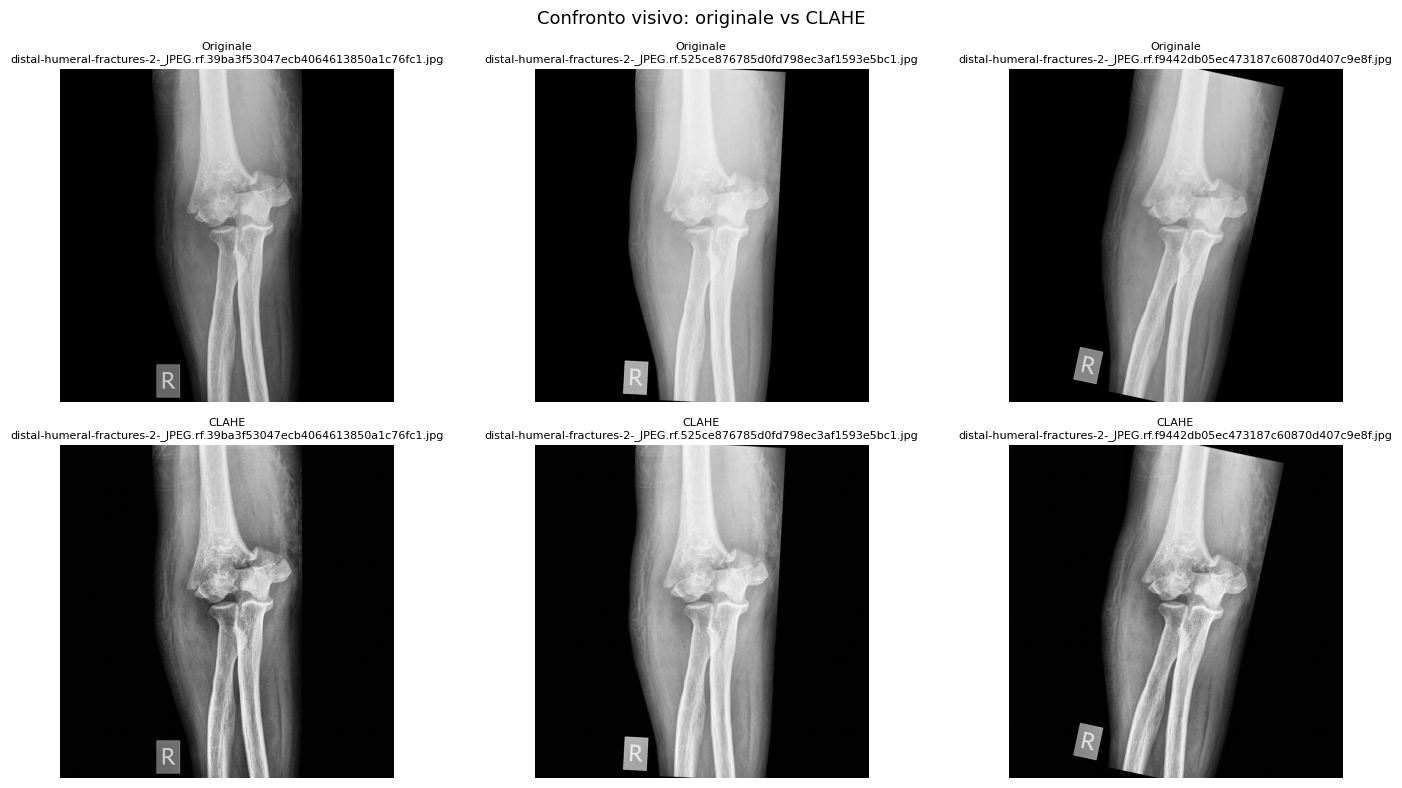

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

train_img_orig  = PKDARABI_PREP  / "train" / "images"
train_img_clahe = PKDARABI_CLAHE / "train" / "images"
train_lbl       = PKDARABI_PREP  / "train" / "labels"

samples = []
for img_path in sorted(train_img_orig.iterdir()):
    lbl = train_lbl / (img_path.stem + ".txt")
    if lbl.exists() and any(l.strip() for l in lbl.read_text().splitlines()):
        samples.append(img_path)
    if len(samples) == 3:
        break

for col, img_path in enumerate(samples):
    img_orig  = np.array(Image.open(img_path).convert("L"))
    img_clahe = np.array(Image.open(train_img_clahe / img_path.name).convert("L"))

    axes[0][col].imshow(img_orig,  cmap="gray", vmin=0, vmax=255)
    axes[0][col].set_title(f"Originale\n{img_path.name}", fontsize=8)
    axes[0][col].axis("off")

    axes[1][col].imshow(img_clahe, cmap="gray", vmin=0, vmax=255)
    axes[1][col].set_title(f"CLAHE\n{img_path.name}", fontsize=8)
    axes[1][col].axis("off")

axes[0][0].set_ylabel("Originale", fontsize=10)
axes[1][0].set_ylabel("CLAHE", fontsize=10)

plt.suptitle("Confronto visivo: originale vs CLAHE", fontsize=13)
plt.tight_layout()
plt.show()


Si vede l'aumento di contrasto, leggero ma presente. Adesso costruisco i fold della K-Fold riusando gli stessi indici della sezione 6, così posso confrontare baseline e CLAHE sullo stesso split.

#### 7.1.1 Materializzazione dei fold CLAHE

Per ogni fold creo le cartelle train/ e val/ con le immagini CLAHE già preprocessate, usando gli indici della sezione 6. Se un fold è già stato creato la cella lo salta.

In [6]:
PKDARABI_CLAHE_KFOLD = DATASETS_DIR / "preprocessed" / "pkdarabi_clahe_kfold"


In [20]:
def materialize_clahe_fold(fold_idx, train_idx, val_idx):
    fold_dir = PKDARABI_CLAHE_KFOLD / f"fold_{fold_idx}"
    train_img_dir = fold_dir / "train" / "images"
    val_img_dir = fold_dir / "val" / "images"

    # idempotenza: se gia' completo, skip
    if train_img_dir.exists() and val_img_dir.exists():
        actual_train = sum(1 for _ in train_img_dir.iterdir())
        actual_val = sum(1 for _ in val_img_dir.iterdir())
        if actual_train == len(train_idx) and actual_val == len(val_idx):
            print(f"  fold {fold_idx}: gia' presente (train={actual_train}, val={actual_val}), skip")
            return fold_dir

    for split in ("train", "val"):
        (fold_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (fold_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    for split_name, indices in [("train", train_idx), ("val", val_idx)]:
        for i in indices:
            orig_img_path, lbl_path = all_imgs[i]
            # rimpiazza il path originale con la versione CLAHE corrispondente
            rel = orig_img_path.relative_to(PKDARABI_PREP)
            clahe_img_path = PKDARABI_CLAHE / rel

            dst_img = fold_dir / split_name / "images" / orig_img_path.name
            if not dst_img.exists():
                shutil.copy2(clahe_img_path, dst_img)
            dst_lbl = fold_dir / split_name / "labels" / (orig_img_path.stem + ".txt")
            if not dst_lbl.exists():
                if lbl_path is not None:
                    shutil.copy2(lbl_path, dst_lbl)
                else:
                    dst_lbl.write_text("")

    yaml_content = {
        "path" : str(fold_dir.resolve()),
        "train": "train/images",
        "val"  : "val/images",
        "nc"   : 1,
        "names": ["fracture"],
    }
    with open(fold_dir / "data.yaml", "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)

    print(f"  fold {fold_idx}: creato (train={len(train_idx)}, val={len(val_idx)})")
    return fold_dir


PKDARABI_CLAHE_KFOLD.mkdir(parents=True, exist_ok=True)
print(f"Creazione fold CLAHE in: {PKDARABI_CLAHE_KFOLD.resolve()}\n")
for k, (tr, vl) in enumerate(folds):
    materialize_clahe_fold(k, tr, vl)

print("\nFatto.")


Creazione fold CLAHE in: C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe_kfold

  fold 0: creato (train=3318, val=830)
  fold 1: creato (train=3318, val=830)
  fold 2: creato (train=3318, val=830)
  fold 3: creato (train=3319, val=829)
  fold 4: creato (train=3319, val=829)

Fatto.


#### 7.1.2 Training sui 5 fold CLAHE

Stessi iperparametri della baseline (100 epoche, batch=16, imgsz=640, patience=25, augmentation Ultralytics ai default). L'unica cosa che cambia sono i dati. Se il `best.pt` di un fold è già presente, salto il training.

In [21]:
KFOLD_CLAHE_CFG_BASE = {
    "model"    : "yolo11n.pt",
    "imgsz"    : 640,
    "batch"    : 16,
    "epochs"   : 100,
    "patience" : 25,
    "optimizer": "auto",
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "mosaic"   : 1.0,
    "cls"      : 0.5,
    "amp"      : True,
    "project"  : str((BASE_DIR / "runs").resolve()),
    "exist_ok" : False,
}

for k in range(N_FOLDS):
    fold_data_yaml = PKDARABI_CLAHE_KFOLD / f"fold_{k}" / "data.yaml"
    run_name = f"kfold_nano_clahe_fold{k}"
    run_dir = BASE_DIR / "runs" / run_name
    best_pt = run_dir / "weights" / "best.pt"

    if best_pt.exists():
        print(f"=== fold {k}: best.pt gia' presente in {run_dir}, skip ===\n")
        continue

    print(f"\n=== Training CLAHE fold {k}/{N_FOLDS-1} ===")
    cfg = {
        **KFOLD_CLAHE_CFG_BASE,
        "data": str(fold_data_yaml.resolve()),
        "name": run_name,
    }
    model = YOLO(cfg["model"])
    model.train(**cfg)


=== fold 0: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_clahe_fold0, skip ===

=== fold 1: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_clahe_fold1, skip ===

=== fold 2: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_clahe_fold2, skip ===

=== fold 3: best.pt gia' presente in Progetto_DL_1000081957_data\runs\kfold_nano_clahe_fold3, skip ===


=== Training CLAHE fold 4/4 ===
New https://pypi.org/project/ultralytics/8.4.52 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progett

Come prima, se un training si interrompe, imposto `RESUME_CLAHE_FOLD` al fold da riprendere e lancio la cella sotto. Ultralytics riparte da `last.pt` da sola.

In [ ]:
RESUME_CLAHE_FOLD = 0  # cambiare con il fold da riprendere

LAST_PT = BASE_DIR / "runs" / f"kfold_nano_clahe_fold{RESUME_CLAHE_FOLD}" / "weights" / "last.pt"
assert LAST_PT.exists(), f"Checkpoint non trovato: {LAST_PT}"

model_resume = YOLO(str(LAST_PT))
results_resume = model_resume.train(resume=True)


#### 7.1.3 Valutazione e aggregazione

Carico i 5 `best.pt` e valuto ognuno sulla val CLAHE del suo fold. Importante: il modello è stato addestrato su immagini CLAHE, quindi anche la val deve essere CLAHE, altrimenti il confronto non è coerente.

In [22]:
clahe_fold_metrics = []

for k in range(N_FOLDS):
    fold_data_yaml = PKDARABI_CLAHE_KFOLD / f"fold_{k}" / "data.yaml"
    best_pt = BASE_DIR / "runs" / f"kfold_nano_clahe_fold{k}" / "weights" / "best.pt"

    assert best_pt.exists(), f"best.pt non trovato per fold {k}: {best_pt}"

    model_k = YOLO(str(best_pt))
    m = model_k.val(
        data=str(fold_data_yaml.resolve()),
        split="val",
        imgsz=640,
        batch=16,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"kfold_nano_clahe_fold{k}_eval",
        exist_ok=True,
        verbose=False,
    )
    p, r = m.box.mp, m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    clahe_fold_metrics.append({
        "fold": k,
        "mAP50": m.box.map50,
        "mAP50-95": m.box.map,
        "Precision": p,
        "Recall": r,
        "F1": f1,
    })

df_clahe_fold = pd.DataFrame(clahe_fold_metrics)
print("=== Metriche per fold (CLAHE) ===")
print(df_clahe_fold.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== Aggregato CLAHE (media +/- std sui 5 fold) ===")
for col in ("mAP50", "mAP50-95", "Precision", "Recall", "F1"):
    mu, sd = df_clahe_fold[col].mean(), df_clahe_fold[col].std()
    print(f"  {col:<10}: {mu:.4f} +/- {sd:.4f}")


Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 12.51.8 MB/s, size: 25.5 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe_kfold\fold_0\val\labels.cache... 830 images, 418 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.6it/s 11.3s0.2s
                   all        830        474      0.824       0.62      0.731      0.384
Speed: 2.4ms preprocess, 5.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\kfold_nano_clahe_fold0_eval
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA

#### 7.1.4 Risultati K-Fold CLAHE e confronto con baseline

##### Metriche per fold (best epoch sulla val del fold)

| Fold | mAP50  | mAP50-95 | Precision | Recall | F1     |
|------|--------|----------|-----------|--------|--------|
| 0    | 0.7311 | 0.3836   | 0.8241    | 0.6203 | 0.7078 |
| 1    | 0.6420 | 0.3226   | 0.6888    | 0.5831 | 0.6315 |
| 2    | 0.6365 | 0.3169   | 0.6867    | 0.5933 | 0.6366 |
| 3    | 0.6527 | 0.3377   | 0.6858    | 0.5802 | 0.6286 |
| 4    | 0.6537 | 0.3276   | 0.7387    | 0.5655 | 0.6406 |

##### Aggregato sui 5 fold

| Metrica    | Media  | Std    |
|------------|--------|--------|
| mAP50      | 0.6632 | 0.0387 |
| mAP50-95   | 0.3377 | 0.0268 |
| Precision  | 0.7248 | 0.0598 |
| Recall     | 0.5885 | 0.0204 |
| F1         | 0.6490 | 0.0332 |

##### Confronto K-Fold baseline vs K-Fold + CLAHE

| Metrica   | K-Fold Baseline   | K-Fold + CLAHE    | Delta           |
|-----------|-------------------|-------------------|-----------------|
| mAP50     | 0.6501 ± 0.0250   | 0.6632 ± 0.0387   | +0.0131 (+2.0%) |
| mAP50-95  | 0.3277 ± 0.0211   | 0.3377 ± 0.0268   | +0.0100 (+3.1%) |
| Precision | 0.7308 ± 0.0353   | 0.7248 ± 0.0598   | -0.0060 (-0.8%) |
| Recall    | 0.5655 ± 0.0316   | 0.5885 ± 0.0204   | +0.0230 (+4.1%) |
| F1        | 0.6373 ± 0.0288   | 0.6490 ± 0.0332   | +0.0117 (+1.8%) |


Tutte le metriche principali (mAP50, mAP50-95, Recall, F1) salgono un pochino, mentre Precision resta praticamente invariata. È un buon segnale rispetto al tentativo con clipLimit=2.0 (che invece aveva fatto crollare il recall): ridurre l'aggressività di CLAHE ha evitato il danno.

Però il miglioramento va preso con cautela. I delta sono tutti dell'ordine dell'1-4%, più piccoli della deviazione standard di entrambe le condizioni: gli intervalli si sovrappongono. Inoltre il fold 0 si comporta da outlier (mAP50 = 0.7311 contro 0.63-0.65 degli altri quattro): se lo tolgo, la media degli altri fold scende a circa 0.646, sotto la baseline. Quindi il guadagno aggregato è guidato in gran parte da quel singolo fold.

Un'altra cosa che noto: la deviazione standard di mAP50 e Precision cresce con CLAHE (mAP50 da 0.025 a 0.039). CLAHE non ha reso il training più stabile, anzi un filo più variabile tra fold. Il Recall invece è leggermente più stabile (da 0.032 a 0.020), ma su 5 fold soltanto è difficile dire se sia un effetto vero.

In sintesi: CLAHE clipLimit=1.5 non fa danni (a differenza di 2.0) ma neanche migliora in maniera chiara. Probabilmente l'augmentation di default di Ultralytics (mosaic, hflip, HSV) copre già bene il dataset.

### 7.2 Tentativo 2: CLAHE clipLimit=1.0

CLAHE 1.5 ha dato un miglioramento minuscolo (+0.013 mAP50, dentro la deviazione standard), e una parte di questo guadagno è guidata dal fold 0 che si comporta da outlier (mAP50 = 0.7311 contro 0.63-0.65 degli altri quattro fold). Mi viene naturale chiedermi se variando *clipLimit* posso ottenere di meglio: provo a scendere a 1.0, un valore più conservativo che dovrebbe amplificare meno il rumore e preservare meglio la texture originale.

Faccio solo il **fold 0**. So che è un outlier, però la cosa non è un problema per il confronto: la partizione train/val è identica a quella di CLAHE 1.5 sullo stesso fold, quindi i due risultati sono direttamente confrontabili. Anzi, dato che il fold 0 è proprio quello dove CLAHE 1.5 va meglio, è il banco di prova più severo: se CLAHE 1.0 lo battesse anche solo su questo fold, sarebbe un buon indizio che 1.5 non era il valore migliore possibile.

Stesso protocollo del resto (100 epoche, batch=16, imgsz=640, patience=25, augmentation Ultralytics ai default).

In [8]:
# Materializzazione fold 0 con CLAHE clipLimit=1.0 (solo le immagini necessarie).
PKDARABI_CLAHE10_KFOLD = DATASETS_DIR / "preprocessed" / "pkdarabi_clahe10_kfold"

def materialize_clahe_fold_custom(fold_idx, train_idx, val_idx, dst_root, clip_limit, tile_grid_size=(8, 8)):
    fold_dir = dst_root / f"fold_{fold_idx}"
    train_img_dir = fold_dir / "train" / "images"
    val_img_dir = fold_dir / "val" / "images"

    # idempotenza
    if train_img_dir.exists() and val_img_dir.exists():
        actual_train = sum(1 for _ in train_img_dir.iterdir())
        actual_val = sum(1 for _ in val_img_dir.iterdir())
        if actual_train == len(train_idx) and actual_val == len(val_idx):
            print(f"  fold {fold_idx}: gia' presente (train={actual_train}, val={actual_val}), skip")
            return fold_dir

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    for split in ("train", "val"):
        (fold_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (fold_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    for split_name, indices in [("train", train_idx), ("val", val_idx)]:
        for i in indices:
            orig_img_path, lbl_path = all_imgs[i]
            dst_img = fold_dir / split_name / "images" / orig_img_path.name
            if not dst_img.exists():
                img = cv2.imread(str(orig_img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                img_clahe = clahe.apply(img)
                img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2BGR)
                cv2.imwrite(str(dst_img), img_rgb)
            dst_lbl = fold_dir / split_name / "labels" / (orig_img_path.stem + ".txt")
            if not dst_lbl.exists():
                if lbl_path is not None:
                    shutil.copy2(lbl_path, dst_lbl)
                else:
                    dst_lbl.write_text("")

    yaml_content = {
        "path" : str(fold_dir.resolve()),
        "train": "train/images",
        "val"  : "val/images",
        "nc"   : 1,
        "names": ["fracture"],
    }
    with open(fold_dir / "data.yaml", "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)

    print(f"  fold {fold_idx}: creato (train={len(train_idx)}, val={len(val_idx)})")
    return fold_dir


PKDARABI_CLAHE10_KFOLD.mkdir(parents=True, exist_ok=True)
print(f"Materializzo fold 0 con CLAHE clipLimit=1.0 in {PKDARABI_CLAHE10_KFOLD}\n")
materialize_clahe_fold_custom(0, folds[0][0], folds[0][1], PKDARABI_CLAHE10_KFOLD, clip_limit=1.0)
print("\nFatto.")

Materializzo fold 0 con CLAHE clipLimit=1.0 in Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe10_kfold

  fold 0: gia' presente (train=3318, val=830), skip

Fatto.


In [24]:
FOLD_C10 = 0
fold_data_yaml = PKDARABI_CLAHE10_KFOLD / f"fold_{FOLD_C10}" / "data.yaml"
best_pt_c10 = BASE_DIR / "runs" / f"kfold_nano_clahe10_fold{FOLD_C10}" / "weights" / "best.pt"

if best_pt_c10.exists():
    print(f"=== fold {FOLD_C10} (CLAHE clip=1.0): best.pt gia' presente, skip ===")
else:
    print(f"=== Training fold {FOLD_C10} con CLAHE clipLimit=1.0 ===")
    model = YOLO("yolo11n.pt")
    model.train(
        data=str(fold_data_yaml.resolve()),
        epochs=100,
        imgsz=640,
        batch=16,
        patience=25,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"kfold_nano_clahe10_fold{FOLD_C10}",
        exist_ok=False,
        verbose=True,
    )

=== Training fold 0 con CLAHE clipLimit=1.0 ===
New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe10_kfold\fold_0\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.

#### 7.2.1 Risultato: CLAHE 1.0 leggermente sotto a CLAHE 1.5

| Condizione         | mAP50  | mAP50-95 | Precision | Recall | F1     |
|--------------------|--------|----------|-----------|--------|--------|
| **CLAHE clip=1.5** | **0.7311** | **0.3836** | 0.8241    | **0.6203** | **0.7078** |
| CLAHE clip=1.0     | 0.7189 | 0.3565   | **0.8294** | 0.5745 | 0.6788 |

Sul fold 0 clip=1.0 perde -0.012 mAP50 e -0.027 mAP50-95 contro clip=1.5, con Precision quasi uguale (+0.005) ma Recall in calo abbastanza marcato (-0.046). Tutto sommato è quello che ci si aspetta: meno contrasto = modello più cauto (Precision leggermente sopra) ma si perdono le fratture meno evidenti (Recall sotto), che però in radiografia sono proprio quelle che interessa trovare.

Il segno del risultato è chiaro ma su un fold solo non posso escludere del tutto che sia rumore di split. Il calo di Recall però è abbastanza grande (-0.046, oltre 2 deviazioni standard della baseline) da far pensare che clip=1.0 non sia preferibile a clip=1.5 in questo caso.

**Esito**: scendere a 1.0 non migliora, quindi clipLimit=1.5 resta la scelta migliore tra le due.

### 7.3 Tentativo 3: Augmentation soft

CLAHE ha migliorato di pochissimo, e variandone il clipLimit non sono riuscito a fare meglio. Provo allora a giocare anche sugli iperparametri di augmentation di Ultralytics, che nella baseline erano tutti ai default. Questi agiscono *online*: a ogni epoca il modello vede una versione diversa dell'immagine, senza bisogno di riscrivere il dataset su disco.

Voglio essere prudente per non rovinare quello che ha già la baseline, quindi parto da una configurazione leggera (`AUG_CFG_SOFT`), toccando solo due parametri:

- **degrees=8.0** — rotazioni fino a ±8°. Le radiografie vengono acquisite con angolazioni un po' diverse tra esami e tecnici, quindi un po' di rotazione è realistica.
- **shear=1.0** — leggera deformazione di taglio, per simulare proiezioni un po' oblique.

Dato che i fold sono fissi (gli stessi della sezione 6), confrontare una nuova configurazione con la baseline sullo stesso fold dà un confronto diretto: stessa partizione train/val, stessi pesi iniziali, l'unica cosa che cambia è l'augmentation. Quindi posso decidere con un solo fold se ha senso fare tutti i 5.

Parto dal **fold 0**: la sua mAP50 di baseline (0.6453) è molto vicina alla media dei 5 fold (0.6501), quindi non è un fold particolarmente facile né difficile.

In [25]:
AUG_CFG_SOFT = dict(
    degrees=8.0,
    shear=1.0,
)

FOLD_SOFT = 0
fold_data_yaml = PKDARABI_KFOLD / f"fold_{FOLD_SOFT}" / "data.yaml"
best_pt_soft = BASE_DIR / "runs" / f"kfold_nano_aug_soft_fold{FOLD_SOFT}" / "weights" / "best.pt"

if best_pt_soft.exists():
    print(f"=== fold {FOLD_SOFT} (aug soft): best.pt gia' presente, skip ===")
else:
    print(f"=== Training fold {FOLD_SOFT} con AUG_CFG_SOFT ===")
    model = YOLO("yolo11n.pt")
    model.train(
        data=str(fold_data_yaml.resolve()),
        epochs=100,
        imgsz=640,
        batch=16,
        patience=25,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"kfold_nano_aug_soft_fold{FOLD_SOFT}",
        exist_ok=False,
        verbose=True,
        **AUG_CFG_SOFT,
    )

=== fold 0 (aug soft): best.pt gia' presente, skip ===


In [11]:
FOLDS_CMP = [0, 1]

conditions = [
    ("Baseline",   "kfold_nano_fold{k}",          PKDARABI_KFOLD),
    ("CLAHE",      "kfold_nano_clahe_fold{k}",    PKDARABI_CLAHE_KFOLD),
    ("Aug soft",   "kfold_nano_aug_soft_fold{k}", PKDARABI_KFOLD),
]

rows = []
for k in FOLDS_CMP:
    for label, run_tpl, data_root in conditions:
        run_name = run_tpl.format(k=k)
        best_pt = BASE_DIR / "runs" / run_name / "weights" / "best.pt"
        assert best_pt.exists(), f"best.pt non trovato per {label} fold {k}: {best_pt}"

        fold_data_yaml = data_root / f"fold_{k}" / "data.yaml"
        model_k = YOLO(str(best_pt))
        m = model_k.val(
            data=str(fold_data_yaml.resolve()),
            split="val",
            imgsz=640,
            batch=16,
            project=str((BASE_DIR / "runs").resolve()),
            name=f"{run_name}_cmp_soft",
            exist_ok=True,
            verbose=False,
        )
        p, r = m.box.mp, m.box.mr
        f1 = 2 * p * r / (p + r + 1e-9)
        rows.append({
            "fold": k,
            "Condizione": label,
            "mAP50": m.box.map50,
            "mAP50-95": m.box.map,
            "Precision": p,
            "Recall": r,
            "F1": f1,
        })

df_cmp_soft = pd.DataFrame(rows)

# Stampa per-fold
for k in FOLDS_CMP:
    print(f"=== Confronto su fold {k} ===")
    sub = df_cmp_soft[df_cmp_soft["fold"] == k].drop(columns=["fold"])
    print(sub.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()

# Media sui fold valutati
if len(FOLDS_CMP) > 1:
    print(f"=== Media sui fold {FOLDS_CMP} ===")
    agg = df_cmp_soft.groupby("Condizione", sort=False)[["mAP50", "mAP50-95", "Precision", "Recall", "F1"]].mean()
    print(agg.to_string(float_format=lambda x: f"{x:.4f}"))

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 32.24.6 MB/s, size: 10.9 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_kfold\fold_0\val\labels.cache... 830 images, 418 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 5.7it/s 9.1s0.2s
                   all        830        474      0.708      0.555      0.645      0.317
Speed: 1.6ms preprocess, 2.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\kfold_nano_fold0_cmp_soft
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce 

#### 7.3.1 Verifica su 2 fold e decisione

Dopo il segnale positivo sul fold 0 (Aug soft 0.6981 vs baseline 0.6453, +0.053), ho fatto anche il fold 1 e ho valutato sui 2 fold tutte e 3 le condizioni in gioco.

##### Risultati su fold 0 e fold 1

| Fold | Condizione | mAP50  | mAP50-95 | Precision | Recall | F1     |
|------|------------|--------|----------|-----------|--------|--------|
| 0    | Baseline   | 0.6453 | 0.3165   | 0.7076    | 0.5549 | 0.6220 |
| 0    | **CLAHE**  | **0.7311** | **0.3836** | **0.8241** | **0.6203** | **0.7078** |
| 0    | Aug soft   | 0.6981 | 0.3607   | 0.7663    | 0.6013 | 0.6738 |
| 1    | Baseline   | 0.6615 | 0.3275   | 0.6984    | 0.5934 | 0.6416 |
| 1    | CLAHE      | 0.6420 | 0.3226   | 0.6888    | 0.5831 | 0.6315 |
| 1    | **Aug soft** | **0.6454** | **0.3299** | **0.7324** | **0.5643** | **0.6375** |

##### Media sui 2 fold

| Condizione | mAP50  | mAP50-95 | Precision | Recall | F1     |
|------------|--------|----------|-----------|--------|--------|
| Baseline   | 0.6534 | 0.3220   | 0.7030    | 0.5742 | 0.6318 |
| **CLAHE**  | **0.6866** | **0.3531** | **0.7565** | **0.6017** | **0.6697** |
| Aug soft   | 0.6718 | 0.3453   | 0.7494    | 0.5828 | 0.6557 |

##### Lettura: Aug soft più o meno come CLAHE, non meglio

Sul fold 0 CLAHE batte Aug soft chiaramente (+0.033 mAP50). Sul fold 1 invece Aug soft batte CLAHE, ma per pochissimo (+0.003 mAP50), praticamente rumore. In media sui 2 fold CLAHE è davanti di +0.015 mAP50 e +0.008 mAP50-95, e sono delta dentro la deviazione standard di CLAHE (0.039 sui 5 fold). Quindi le due configurazioni sono di fatto alla pari.

##### Decisione: non estendo Aug soft ai 5 fold

I motivi:
1. su 2 fold il margine contro CLAHE è negativo o trascurabile;
2. la media CLAHE sui 5 fold (0.6632), togliendo il fold 0 outlier (0.7311), scende a circa 0.646, molto vicino al fold 1 di Aug soft (0.645). La previsione realistica è che Aug soft sui 3 fold rimanenti finisca intorno a 0.65 ± 0.03, esattamente come CLAHE;
3. spendere ~5h di GPU per confermare un pareggio non sembra una buona idea.

**Esito**: Aug soft recupera la baseline e ci aggiunge un piccolo guadagno, ma non riesce a superare CLAHE 1.5.

### 7.4 Tentativo 4: CLAHE 1.5 + Aug soft

A questo punto ho due cose che migliorano leggermente la baseline, ognuna per conto suo: CLAHE 1.5 (preprocessing *offline*, agisce sui valori dei pixel) e Aug soft (augmentation *online*, agisce sulle coordinate). Visto che lavorano a livelli diversi, mi sembra plausibile che siano ortogonali e che i loro effetti si sommino: provo a metterli insieme per vedere se la combinazione finisce sopra entrambe.

Faccio solo il **fold 0** come test rapido: è lo stesso che ho usato per gli altri confronti, quindi è confrontabile sia con CLAHE 1.5 da solo (0.7311 mAP50) sia con Aug soft da solo (0.6981).

Configurazione:
- Dataset: PKDARABI_CLAHE_KFOLD (CLAHE 1.5 già applicato).
- Augmentation: AUG_CFG_SOFT (degrees=8, shear=1).
- Pesi iniziali: yolo11n.pt.
- Stesso protocollo del resto (100 epoche, batch=16, imgsz=640, patience=25).

In [26]:
FOLD_COMBO = 0
fold_data_yaml = PKDARABI_CLAHE_KFOLD / f"fold_{FOLD_COMBO}" / "data.yaml"
best_pt_combo = BASE_DIR / "runs" / f"kfold_nano_clahe_aug_soft_fold{FOLD_COMBO}" / "weights" / "best.pt"

if best_pt_combo.exists():
    print(f"=== fold {FOLD_COMBO} (CLAHE + aug soft): best.pt gia' presente, skip ===")
else:
    print(f"=== Training fold {FOLD_COMBO} con CLAHE preprocessing + AUG_CFG_SOFT ===")
    model = YOLO("yolo11n.pt")
    model.train(
        data=str(fold_data_yaml.resolve()),
        epochs=100,
        imgsz=640,
        batch=16,
        patience=25,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"kfold_nano_clahe_aug_soft_fold{FOLD_COMBO}",
        exist_ok=False,
        verbose=True,
        **AUG_CFG_SOFT,
    )

=== Training fold 0 con CLAHE preprocessing + AUG_CFG_SOFT ===
New https://pypi.org/project/ultralytics/8.4.53 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_clahe_kfold\fold_0\data.yaml, degrees=8.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=

In [10]:
# Confronto fold 0: tutte le condizioni in gioco + CLAHE+Aug soft.
# La val di CLAHE-based e' su immagini CLAHE-preprocessate (coerenza train/val).
FOLD_CMP = 0

conditions = [
    ("Baseline",         f"kfold_nano_fold{FOLD_CMP}",                PKDARABI_KFOLD),
    ("CLAHE",            f"kfold_nano_clahe_fold{FOLD_CMP}",          PKDARABI_CLAHE_KFOLD),
    ("Aug soft",         f"kfold_nano_aug_soft_fold{FOLD_CMP}",       PKDARABI_KFOLD),
    ("CLAHE + Aug soft", f"kfold_nano_clahe_aug_soft_fold{FOLD_CMP}", PKDARABI_CLAHE_KFOLD),
]

rows = []
for label, run_name, data_root in conditions:
    best_pt = BASE_DIR / "runs" / run_name / "weights" / "best.pt"
    assert best_pt.exists(), f"best.pt non trovato per {label}: {best_pt}"

    fold_data_yaml = data_root / f"fold_{FOLD_CMP}" / "data.yaml"
    model_k = YOLO(str(best_pt))
    m = model_k.val(
        data=str(fold_data_yaml.resolve()),
        split="val",
        imgsz=640,
        batch=16,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"{run_name}_cmp_combo",
        exist_ok=True,
        verbose=False,
    )
    p, r = m.box.mp, m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    rows.append({
        "Condizione": label,
        "mAP50": m.box.map50,
        "mAP50-95": m.box.map,
        "Precision": p,
        "Recall": r,
        "F1": f1,
    })

df_cmp_combo = pd.DataFrame(rows)
print(f"=== Confronto fold {FOLD_CMP}: tutte le condizioni ===")
print(df_cmp_combo.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 36.68.4 MB/s, size: 10.8 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_kfold\fold_0\val\labels.cache... 830 images, 418 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 5.6it/s 9.4s0.2s
                   all        830        474      0.708      0.555      0.645      0.317
Speed: 1.7ms preprocess, 2.9ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\kfold_nano_fold0_cmp_combo
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce

#### 7.4.1 Risultato

| Condizione               | mAP50  | mAP50-95 | Precision | Recall | F1     |
|--------------------------|--------|----------|-----------|--------|--------|
| CLAHE 1.5 (solo)         | 0.7311 | 0.3836   | 0.8241    | 0.6203 | 0.7078 |
| Aug soft (solo)          | 0.6981 | 0.3607   | 0.7663    | 0.6013 | 0.6738 |
| **CLAHE 1.5 + Aug soft** | **0.6626** | **0.3349** | **0.7346** | **0.5696** | **0.6417** |

La combinazione sul fold 0 fa **0.6626 mAP50**, cioè -0.069 rispetto a CLAHE da solo e -0.036 rispetto a Aug soft da solo. L'ipotesi che fossero ortogonali era sbagliata: i due interventi interferiscono.

**Esito**: chiudo il tentativo combinato. Non vale la pena fare gli altri 4 fold.

### 7.5 Sintesi finale e scelta

#### Riepilogo dei tentativi

| # | Configurazione         | Fold valutati  | mAP50               | mAP50-95            | Note |
|---|------------------------|----------------|---------------------|---------------------|------|
| - | Baseline (no aug.)     | 5              | 0.6501 ± 0.0250     | 0.3277 ± 0.0211     | riferimento sezione 6 |
| 1 | **CLAHE clipLimit=1.5** | **5**         | **0.6632 ± 0.0387** | **0.3377 ± 0.0268** | **+0.013 mAP50**, dentro la deviazione standard |
| 2 | CLAHE clipLimit=1.0    | 1 (fold 0)     | 0.7189              | 0.3565              | -0.012 vs CLAHE 1.5 fold 0; Recall in calo |
| 3 | Aug soft               | 2              | 0.6718 (media)      | 0.3453 (media)      | più o meno come CLAHE 1.5 |
| 4 | CLAHE 1.5 + Aug soft   | 1 (fold 0)     | 0.6626              | 0.3349              | -0.069 vs CLAHE 1.5 fold 0; interferenza |

#### Confronto sul fold 0 (tutte le condizioni)

La cella sotto stampa il confronto sul fold 0 per tutte le configurazioni provate (Baseline, CLAHE 1.5, CLAHE 1.0, Aug soft, CLAHE 1.5 + Aug soft).

In [9]:
# Confronto finale sul fold 0: tutte le condizioni della sezione 7 in ordine narrativo.
FOLD_CMP = 0

conditions = [
    ("Baseline",             f"kfold_nano_fold{FOLD_CMP}",                PKDARABI_KFOLD),
    ("CLAHE clip=1.5",       f"kfold_nano_clahe_fold{FOLD_CMP}",          PKDARABI_CLAHE_KFOLD),
    ("CLAHE clip=1.0",       f"kfold_nano_clahe10_fold{FOLD_CMP}",        PKDARABI_CLAHE10_KFOLD),
    ("Aug soft",             f"kfold_nano_aug_soft_fold{FOLD_CMP}",       PKDARABI_KFOLD),
    ("CLAHE 1.5 + Aug soft", f"kfold_nano_clahe_aug_soft_fold{FOLD_CMP}", PKDARABI_CLAHE_KFOLD),
]

rows = []
for label, run_name, data_root in conditions:
    best_pt = BASE_DIR / "runs" / run_name / "weights" / "best.pt"
    assert best_pt.exists(), f"best.pt non trovato per {label}: {best_pt}"

    fold_data_yaml = data_root / f"fold_{FOLD_CMP}" / "data.yaml"
    model_k = YOLO(str(best_pt))
    m = model_k.val(
        data=str(fold_data_yaml.resolve()),
        split="val",
        imgsz=640,
        batch=16,
        project=str((BASE_DIR / "runs").resolve()),
        name=f"{run_name}_cmp_final",
        exist_ok=True,
        verbose=False,
    )
    p, r = m.box.mp, m.box.mr
    f1 = 2 * p * r / (p + r + 1e-9)
    rows.append({
        "Condizione": label,
        "mAP50": m.box.map50,
        "mAP50-95": m.box.map,
        "Precision": p,
        "Recall": r,
        "F1": f1,
    })

df_cmp_final = pd.DataFrame(rows)
print(f"=== Confronto finale sul fold {FOLD_CMP} ===")
print(df_cmp_final.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 5.91.0 MB/s, size: 10.1 KB)
val: Scanning C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\datasets\preprocessed\pkdarabi_kfold\fold_0\val\labels.cache... 830 images, 418 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.4it/s 11.8s0.2s
                   all        830        474      0.708      0.555      0.645      0.317
Speed: 2.0ms preprocess, 5.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to C:\Users\emm97\Desktop\Deep Learning\Esame\Progetto\Progetto_DL_1000081957_data\runs\kfold_nano_fold0_cmp_final
Ultralytics 8.4.46  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce

#### Scelta: CLAHE clipLimit=1.5

CLAHE clipLimit=1.5 è la scelta migliore tra quelle che ho provato:
1. è l'unica configurazione la cui media sui 5 fold è sopra la baseline (anche se entro rumore);
2. sul fold 0 batte tutte le altre configurazioni provate;
3. ha il Recall più alto, che in un contesto come la diagnosi di fratture è importante (è peggio mancare una frattura che dare un falso allarme).

Il guadagno aggregato vs baseline è di +0.013 mAP50, dentro la deviazione standard di entrambe le condizioni. Non posso quindi parlare di miglioramento davvero significativo: CLAHE *non danneggia* il modello e mostra una leggera tendenza positiva, però guidata in larga parte dal fold 0 outlier.

Operativamente, **uso CLAHE clipLimit=1.5 come preprocessing per il resto del progetto**, sapendo che il guadagno è modesto. Il margine di miglioramento più grande va probabilmente cercato nell'allenamento (hyperparameter tuning) o nella capacità del modello (yolo11s), non più nell'augmentation.